In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

We shall next study Gaussian process regression. The most canonical example of a Gaussian process is the Brownian Motion. Here is how it can be simulated. 

## Brownian Motion

$B_t$ is Brownian motion. The following algorithm simulates Brownian Motion on $[0, M]$ for some fixed $M$ (e.g.,  $M = 65$). 

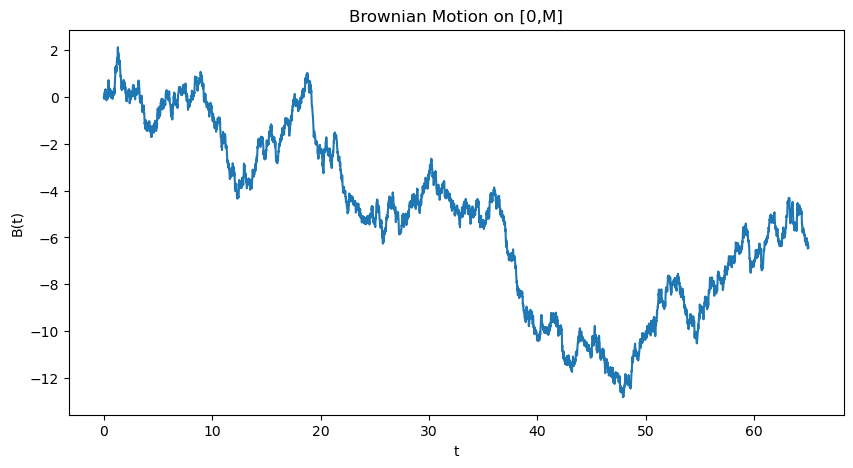

In [3]:
M = 65         # time horizon
N = 5000        # number of grid points
dt = M / N       # step size

t = np.linspace(0, M, N+1)

# generate increments
increments = np.sqrt(dt) * np.random.randn(N)

# Brownian path
B = np.zeros(N+1)
B[1:] = np.cumsum(increments)

plt.figure(figsize=(10, 5))
plt.plot(t, B)
plt.xlabel("t")
plt.ylabel("B(t)")
plt.title("Brownian Motion on [0,M]")
plt.show()


In the plot above, successive values are joined by straight lines. We can also plot by assuming that the value is constant in between successive values. This is done below.

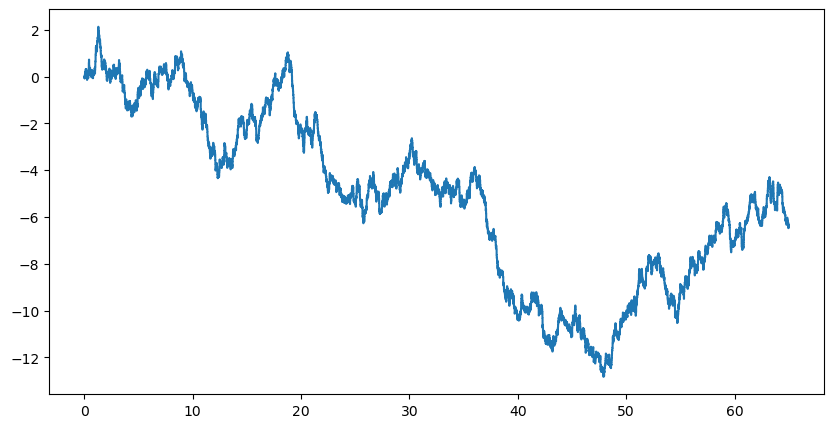

In [5]:
plt.figure(figsize=(10, 5))
plt.step(t, B, where="post")
plt.show()

When $N$ is large, we cannot spot any differences between the above two plots (the differences are much more apparent when $N$ is small). 

Note here that $t_i = i M/N$ for $i = 0, \dots, N$. In the second plot (plt.step) above, what we are plotting is: 
\begin{align*}
   \sum_{i=1}^N \alpha_i I\{t \geq i M/N \}
\end{align*}
where $\alpha_i := B(t_i) - B(t_{i-1}) \overset{\text{i.i.d}}{\sim} N(0, M/N)$. We are thus using the approximation: 
\begin{align*}
   B(t) \approx \sum_{i=1}^N \alpha_i I \{t \geq i M/N \}. 
\end{align*}
The implies the following ReLU approximation to Integrated Brownian Motion. 
\begin{align*}
   I(t) = \int_0^t B(s) ds \approx \sum_{i=1}^N \alpha_i \int_0^t I\{s \geq iM/N\} ds = \sum_{i=1}^N \alpha_i (t - iM/N)_+
\end{align*}
